In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from ant.market import Market, BaseAgent
from ant.decentralised.direct import ProportionalAgent, EqualDivisionAgent, OptimalAgent, GreedyAgent
from ant.decentralised.special_strategies import EgalitarianAgent, PettyAgent, ImitationAgent
from ant.centralised import P4

In [2]:
market_size = 50
simulation_length = 400
num_repeats = 30

graph_types = ["complete", "random", "grid", "scale-free", "Small-World"]

# Dictionary to store all simulation results across the 30 repeats
# Format: all_results[graph_type] = list of 30 simulation result arrays
all_results = {gtype: [] for gtype in graph_types}

In [3]:
for repeat in range(num_repeats):
    print(f"Running repeat {repeat + 1}/{num_repeats}...")
    # Vary the seed for each repeat to ensure different random topologies and agent setups
    current_seed = 25 + repeat
    
    graphs = {
        "complete": nx.complete_graph(market_size),
        "random": nx.gnp_random_graph(market_size, 0.11, seed=current_seed),
        "grid" : nx.convert_node_labels_to_integers(nx.grid_2d_graph(5, 10)),
        "scale-free" : nx.barabasi_albert_graph(market_size, 1, seed=current_seed),
        "Small-World": nx.watts_strogatz_graph(market_size, int(market_size / 2), 0.05, seed=current_seed),
    }

    for graph_type, graph in graphs.items():
        _market = Market(market_size, graph=graph, seed=current_seed, agent_type=GreedyAgent)
        optimal_aloc, utility_vec = P4(_market)
        _market.set_market_equilibrium(optimal_aloc, utility_vec)
        
        simulated_state = _market.simulate(simulation_length)
        all_results[graph_type].append(simulated_state)

Running repeat 1/30...


/Users/maxeradus/Documents/00 TU Delft/y3/3000 Research project/research repo/Ant/src/ant/centralised.py:50: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  result = prob.solve()


Running repeat 2/30...


/Users/maxeradus/Documents/00 TU Delft/y3/3000 Research project/research repo/Ant/.venv/lib/python3.14/site-packages/cvxpy/atoms/elementwise/log.py:35: RuntimeWarning: invalid value encountered in log
  return np.log(values[0])


Running repeat 3/30...
Running repeat 4/30...
Running repeat 5/30...
Running repeat 6/30...
Running repeat 7/30...
Running repeat 8/30...
Running repeat 9/30...
Running repeat 10/30...
Running repeat 11/30...
Running repeat 12/30...
Running repeat 13/30...
Running repeat 14/30...
Running repeat 15/30...
Running repeat 16/30...
Running repeat 17/30...
Running repeat 18/30...
Running repeat 19/30...
Running repeat 20/30...
Running repeat 21/30...
Running repeat 22/30...
Running repeat 23/30...
Running repeat 24/30...
Running repeat 25/30...
Running repeat 26/30...
Running repeat 27/30...
Running repeat 28/30...
Running repeat 29/30...
Running repeat 30/30...


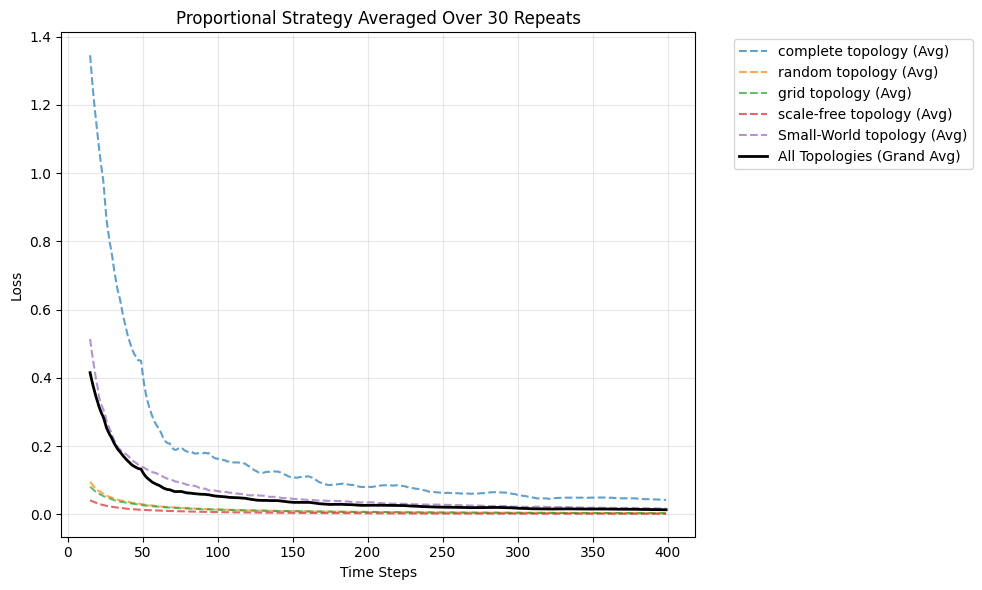

In [5]:
training_period = 15
time_steps = np.arange(training_period, simulation_length)

plt.figure(figsize=(10, 6))

all_topologies_average = []

for graph_type in graph_types:
    # Array shape: (30, simulation_length)
    states_array = np.array(all_results[graph_type])
    
    # Calculate the average loss per timestep across the 30 repeats
    avg_state = np.mean(states_array, axis=0)
    all_topologies_average.append(avg_state)
    
    plt.plot(
        time_steps,
        avg_state[training_period:],
        label=f"{graph_type} topology (Avg)",
        alpha=0.7,
        linestyle="--"
    )

# Calculate the grand average per timestep over ALL topologies and repeats
grand_average = np.mean(all_topologies_average, axis=0)

plt.plot(
    time_steps,
    grand_average[training_period:],
    label="All Topologies (Grand Avg)",
    color="black",
    linewidth=2,
    alpha=1
)

plt.xlabel("Time Steps")
plt.ylabel("Loss")
plt.title(f"Proportional Strategy Averaged Over {num_repeats} Repeats")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()